<a href="https://colab.research.google.com/github/artport-max/AIFFEL_quest_eng/blob/main/NLP/NLP05/Autogen_AgentChat_%EB%AF%B8%EC%88%A0%EB%B9%84%ED%8F%89.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Last modified : 2026.03
작성 : 박광석(모두의연구소, https://www.linkedin.com/in/andkspark) , 2025.03


AutoGen은 Microsoft에서 개발한 멀티 에이전트 프레임워크로,
여러 개의 LLM 기반 에이전트들이 역할을 나누고 상호작용하며 협업적으로 문제를 해결할 수 있도록 설계된 오픈소스 시스템입니다! AutoGen은 다음의 특징을 가지고 있습니다.  

🧠 대화 기반의 워크플로우 구성  
에이전트 간 메시지 기반 커뮤니케이션을 통해, 사용자가 정의한 목표에 따라 작업을 진행합니다.

⚙️ 역할 기반 설계  
각 에이전트는 ‘코드 작성자’, ‘검토자’, ‘실행자’ 등 구체적인 역할을 갖고, 협업 구조를 자유롭게 정의할 수 있습니다.

🔁 루프 기반 상호 피드백 구조  
하나의 에이전트가 출력한 결과를 다른 에이전트가 검토하고 피드백하며, 여러 라운드에 걸쳐 개선된 결과를 도출합니다.

🔌 LLM/툴 통합 유연성  
OpenAI, Azure, HuggingFace 등 다양한 LLM API를 연결할 수 있고, Python 코드 실행이나 외부 시스템 연동 또한 지원합니다.

위 내용을 버그 수정 프로세스의 예시를 들어 다시 설명해보겠습니다.

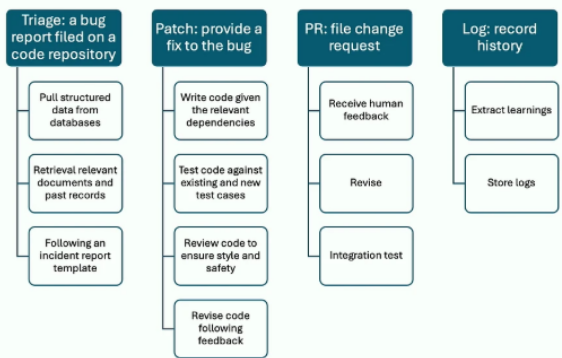

다음 버그 수정 워크플로우가 Autogen의 동작 방식을 잘 보여줍니다! 작업을 단위로 분해하고, 각각을 에이전트에 할당하여 수행하는 방식을 보여줍니다. 전체 워크플로우는 네 단계로, 각 세부 작업은 서로 다른 역할을 가진 에이전트가 맡아 병렬적이고 협력적으로 수행합니다.

1. Triage (버그 분류) 단계,

하나의 에이전트가 관련 데이터를 데이터베이스에서 추출하고,

다른 에이전트는 과거 사례 및 문서를 검색하며,

또 다른 에이전트는 정형화된 사고 보고서를 작성합니다.

2. Patch (버그 수정) 단계,

한 에이전트가 종속성에 맞춰 코드를 작성하고,

또 다른 에이전트는 테스트 케이스 기반으로 기능 검증을 수행합니다.

코드 스타일과 안정성을 리뷰하는 에이전트,

피드백을 반영해 코드를 수정하는 에이전트가 순차적으로 협업합니다.

3. PR (변경 요청) 단계,

한 에이전트가 PR에 대한 피드백을 수집하고,

또 다른 에이전트는 수정을 진행한 후,

통합 테스트를 담당하는 에이전트가 후속 검증을 수행합니다.

4. Log (기록) 단계,

한 에이전트가 학습 가능한 인사이트를 추출하고,

다른 에이전트는 결과를 로그로 저장합니다.

이처럼 AutoGen은 작업을 세분화하고 역할 기반의 에이전트를 조정하여, 사람의 개입 없이도 복잡한 엔지니어링 프로세스를 자동화할 수 있도록 지원합니다.

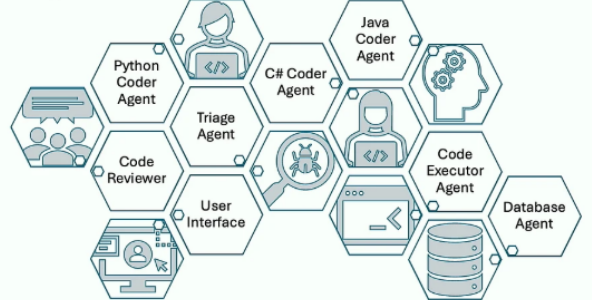

Autogen은 위에 설명했던 여러 에이전트를 내부적으로 구현, 가져다 쓸 수 있는 사용자 편의성을 제공하며, 사용자가 필요에 따라 에이전트와 도구를 직접 정의할 수도 있습니다!

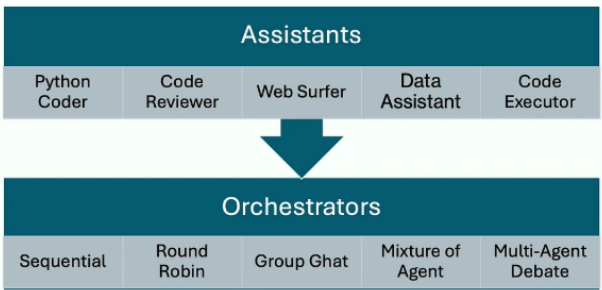

Autogen은 여러 형태로 에이전트간 소통할 수 있는 오케스트레이터를 함께 지원합니다.  
자세한 동작 방식은 다음 튜토리얼 - MultiAgent에서 소개해드릴게요!  

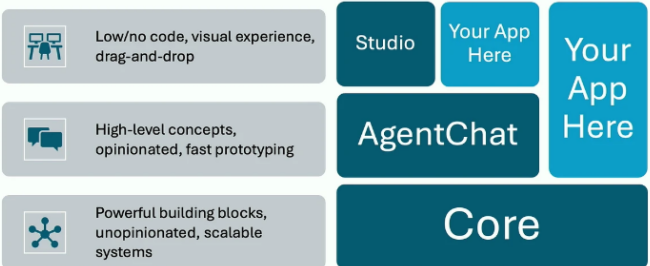

Autogen은 다음의 계층적 아키텍쳐를 가지고 있으며, 목표에 따라 선택하여 사용할 수 있습니다!   

🧱1. Core: 확장성과 유연성을 위한 기반 계층
AutoGen의 Core는 모듈화된 구성요소로 이루어진 핵심 빌딩 블록입니다.
사용자가 직접 시스템을 구성하고, 확장성과 통제력을 갖춘 커스터마이징 가능한 멀티 에이전트 프레임워크를 구축할 수 있도록 지원합니다.
낮은 수준의 제약으로, 복잡하고 대규모인 시스템을 구현하기에 적합합니다.  

💬 2. AgentChat: 빠른 프로토타이핑을 위한 고수준 API 계층
AgentChat은 다양한 역할의 에이전트를 생성하고, 이들 간의 대화 기반 협업 구조를 정의할 수 있는 고수준 프레임워크입니다.
의사결정 흐름을 텍스트 기반 인터페이스로 구성할 수 있어, 빠르게 실험하고 반복할 수 있는 환경을 제공합니다.
구조화된 대화형 시나리오 구현에 적합하며, 기본적인 에이전트 오케스트레이션 기능을 포함합니다.  

🎛️ 3. Studio: 비전문가도 사용할 수 있는 비주얼 에디터 계층
Studio는 시각화 중심의 UI를 제공하여 Low-code/No-code 환경에서 사용자가 직접 워크플로우를 설계하고 조정할 수 있게 해줍니다.
드래그 앤 드롭 방식으로 에이전트를 배치하고 연결할 수 있어, 개발자가 아니어도 쉽고 직관적으로 AutoGen 기반 앱을 구축할 수 있습니다.  
  
요약하자면,

Core → 확장성과 유연성 중심 (전문 개발자용)  
AgentChat → 실험과 구성 간소화 (AI 개발자/연구자용)  
Studio → 직관적인 시각 툴 (비개발자용)  
  
가 되겠습니다!

이번 튜토리얼은 AgentChat으로 진행됩니다!

### Step 0 : 설치와 준비  
Autogen 설치 및 Gemini API 키를 등록하도록 합니다.

In [ ]:
!pip install -U autogen-agentchat autogen-ext[google]

# 설치 후 경로 인식을 위해 가끔 필요합니다.
import site
from importlib import reload
site.main()

In [ ]:
import os

In [ ]:
import sys
# 설치된 패키지를 강제로 찾기 위해 경로 확인
if "/usr/local/lib/python3.12/dist-packages" not in sys.path:
    sys.path.append("/usr/local/lib/python3.12/dist-packages")

try:
    from autogen_agentchat.agents import AssistantAgent
    from autogen_agentchat.base import TaskResult
    from autogen_agentchat.conditions import TextMentionTermination
    from autogen_agentchat.messages import TextMessage
    from autogen_ext.models.openai import OpenAIChatCompletionClient
    print("임포트 성공!")
except ImportError:
    print("여전히 모듈을 찾을 수 없습니다. 상단 메뉴 [런타임] -> [세션 다시 시작]을 누른 후 다시 시도해 주세요.")

임포트 성공!


API KEY는 관리에 유의하시기 바랍니다!

In [ ]:
from google.colab import userdata
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')

AutoGen은 복잡한 워크플로우를 가능하게 하는 오픈 소스 프레임워크로, 에이전트(agent)라는 개념을 중심으로 구성되어 있습니다!  
에이전트는 메시지를 주고받으며, 대형 언어 모델(LLM)이나 코드 실행기, 인간의 입력 등 다양한 구성 요소를 통해 응답을 생성할 수 있고, 외부 함수나 도구를 호출하여 특정 작업을 수행할 수 있도록 지원합니다.

### Step 1 : 에이전트 정의하기
Autogen에서는 이름과 시스템 메세지, 그리고 model client 만으로
매우 간편하게 에이전트를 정의할 수 있습니다!
  
model client는 "에이전트가 LLM(예: GPT-4)이랑 대화할 수 있게 해주는 연결 다리" 입니다. 다양한 모델의 API간의 다른 모델 호출 방식을 Autogen 코드 내에서 통일된 방식으로 접근할 수 있게 해줍니다.  
  
실습 코드에서 사용하는 OpenAIChatCompletionClient 는 OpenAI의 모델, 혹은 OpenAI API와 호환을 제공하는 모델 (예 : Gemini) 을 사용할 수 있습니다.  
그 외에도 Azure OpenAI models 을 지원하는 AzureOpenAIChatCompletionClient, Claude 등의 Anthropic 모델 /  Ollema 을 지원하는 AnthropicChatCompletionClient / OllamaChatCompletionClient 가 있으며, semanticp-kernel 을 이용해 mistral, aws, huggingface의 모델을 사용할 수 있는 SKChatCompletionAdapter 도 지원합니다.




In [ ]:
from autogen_agentchat.agents import AssistantAgent
from autogen_ext.models.openai import OpenAIChatCompletionClient

# Google Gemini API를 위한 설정 (OpenAI 호환 모드)
# 유저님의 요청대로 Google 모델(gemini-2.5-flash)을 사용합니다.
model_client = OpenAIChatCompletionClient(
    model="gemini-2.5-flash",
    api_key=GOOGLE_API_KEY,
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/",
    model_info={
        "model": "gemini-2.5-flash",
        "family": "gemini",
        "context_window": 128000,
        "supports_tools": True,
        "vision": True,
        "function_calling": True,
        "json_output": True,
        "structured_output": True,
    }
)

# 에이전트 정의
agent = AssistantAgent(
    name="assistant",
    model_client=model_client,
    system_message="넌 정말 똑똑한 친구야!",
)

In [ ]:
agent = AssistantAgent(
    name="assistant",
    model_client=model_client,
    system_message="넌 정말 똑똑한 친구야!",
)

### Step 2 : 메세지 보내기

Autogen은 에이전트를 여럿 두고 대화를 주고받는 형태로 시스템을 구성합니다.  물론 유저 또한 에이전트와 대화를 주고받을 수 있습니다!  
단일 에이전트와 Message를 통하여 대화를 주고받아보도록 하겠습니다.

면밀한 관찰을 위해 해당 실습에서는 autogen을 비동기식 (async) 으로 사용합니다.비동기식으로 autogen을 사용할 경우, 지연상황을 발생시키지 않기 위해 CancellationToken을 함께 사용합니다.
  
CancellationToken은 autogen.core 라이브러리에 정의되어 있습니다.

In [ ]:
from autogen_core import CancellationToken

메세지에는 source가 함께 표기됩니다. 이후 진행해볼 에이전트간의 대화에서는 메세지를 발신한 에이전트의 정보가 표시됩니다.

In [ ]:
text_message = TextMessage(content="Hello World! Let's build with AI", source="User")
text_message

TextMessage(id='65abef1a-7944-4094-94a9-6d39f724dc85', source='User', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 3, 21, 12, 49, 48, 633507, tzinfo=datetime.timezone.utc), content="Hello World! Let's build with AI", type='TextMessage')

정의한 메세지로 에이전트와 대화해보겠습니다.
on_messages 메소드를 사용하여 정의한 메세지를 주입합니다.

In [ ]:
try:
    response = await agent.on_messages(
        [text_message], cancellation_token=CancellationToken()
    )
    print("<USER> : ", text_message.content)
    print("<ASSISTANT> : ", response.chat_message.content)
    print("API key is valid and the agent responded successfully.")
except Exception as e:
    print(f"API Key validation failed: {e}")
    print("Please check your Gemini API key in Google AI Studio or Google Cloud Console to ensure it is valid and linked to a billing-enabled project.")


<USER> :  Hello World! Let's build with AI
<ASSISTANT> :  Hello World indeed! I love the enthusiasm and the call to action. I'm ready!

Building with AI opens up incredible possibilities across almost every domain imaginable.

To kick things off, what kind of project do you have in mind? We could go in so many directions!

*   **Are you thinking about something creative?** (e.g., story generation, art creation, music composition)
*   **Something analytical?** (e.g., data insights, prediction models, trend analysis)
*   **Something practical for automation or assistance?** (e.g., a chatbot, a task organizer, a smart assistant)
*   **Do you have a specific problem you want to solve, a concept you want to explore, or a type of AI you're particularly interested in** (like natural language processing, computer vision, predictive analytics, etc.)?
*   **What's your goal?**

Just tell me where you'd like to start, and let's get building!
API key is valid and the agent responded successfully.


In [ ]:
async def assistant_run() -> None:
    response = await agent.on_messages(
        [TextMessage(content="3 * 4 가 뭐야?", source="user")],
        cancellation_token=CancellationToken(),
    )
    print("<USER> : ", "3 * 4 가 뭐야?")
    print("<ASSISTANT> : ", response.chat_message.content)

await assistant_run()

<USER> :  3 * 4 가 뭐야?
<ASSISTANT> :  3 * 4 = 12 입니다.


## 사용 가능한 Gemini 모델 목록 확인

API 키와 현재 구성으로 사용 가능한 Gemini 모델 목록을 확인하는 코드를 실행합니다. 이를 통해 정확한 모델 이름을 파악할 수 있습니다.

In [ ]:
import google.generativeai as genai
from google.colab import userdata

GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

print("사용 가능한 Gemini 모델 목록:")
for m in genai.list_models():
    if "generateContent" in m.supported_generation_methods:
        print(m.name)

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


사용 가능한 Gemini 모델 목록:
models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-2.5-flash-lite-preview-09-2025
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-robotics-er-1.5-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-pro-preview-12-2025


In [ ]:
from autogen_agentchat.agents import AssistantAgent
from autogen_ext.models.openai import OpenAIChatCompletionClient

# Google Gemini API를 위한 설정 (OpenAI 호환 모드)
model_client = OpenAIChatCompletionClient(
    model="gemini-2.5-flash",
    api_key=GOOGLE_API_KEY,
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/",
    model_info={
        "model": "gemini-2.5-flash",
        "family": "gemini",
        "context_window": 128000,
        "supports_tools": True,
        "vision": True,
        "function_calling": True,
        "json_output": True,
        "structured_output": True,
    }
)

# 에이전트 정의
agent = AssistantAgent(
    name="assistant",
    model_client=model_client,
    system_message="넌 정말 똑똑한 친구야!",
)

답변은 메세지 객체로 돌아오며, 멤버 변수 content에 접근하여 모델의 출력을 확인할 수 있습니다.

In [ ]:
response = await agent.on_messages(
    [text_message], cancellation_token=CancellationToken()
)
print("<USER> : ", text_message.content)
print("<ASSISTANT> : ", response.chat_message.content)

<USER> :  Hello World! Let's build with AI
<ASSISTANT> :  That's the spirit! Hello World indeed!

I love the enthusiasm. The AI world is vast and exciting, and there's so much we can build together.

What kind of project or area are you most curious about exploring first? Are you thinking about:

*   **Generating text or creative content?** (Like stories, code, poems)
*   **Analyzing data or making predictions?**
*   **Building a conversational AI?** (Like a chatbot)
*   **Image generation or manipulation?**
*   **Something else entirely?**

Let's dive in! What's the first brick you want to lay?


### Step 3 : 툴 사용하기

Agent는 tool을 사용하여 작업을 수행할 수 있습니다.  
Autogen에서 내장형으로 graph RAG, Langchain, mcp, http 도구를 지원하며, 사용자가 tool을 함수로 정의하여 사용할 수도 있습니다.  
  
이 섹션에서는 사용자가 정의한 툴을 사용해보겠습니다.

In [ ]:
from autogen_core.tools import FunctionTool

In [ ]:
import re

async def calculate_expression_func(input_string : str) -> str:
    match = re.search(r'(\d+)\s*([x*/+-])\s*(\d+)', input_string)
    if match:
        num1 = int(match.group(1))
        operator = match.group(2)
        num2 = int(match.group(3))

        if operator == 'x' or operator == '*':
            result = num1 * num2
        elif operator == '/':
            result = num1 / num2
        elif operator == '+':
            result = num1 + num2
        elif operator == '-':
            result = num1 - num2

        result *= 100

        return str(result)

    else:
        return "None"
        # 수식을 찾을 수 없는 경우도구 None 반환

연산 결과의 100배를 돌려주는 함수입니다..!  
함수 정의 후 도구를 생성해줍니다

In [ ]:
# Define a tool that searches the web for information.
calculate_tool = FunctionTool(calculate_expression_func, description = "100배로 반환해주는 도구")

Tool을 생성하면 내부적으로 Schema를 자동으로 생성합니다. 반환은 string으로 수행합니다.  

In [ ]:
calculate_tool.schema

{'name': 'calculate_expression_func',
 'description': '100배로 반환해주는 도구',
 'parameters': {'type': 'object',
  'properties': {'input_string': {'description': 'input_string',
    'title': 'Input String',
    'type': 'string'}},
  'required': ['input_string'],
  'additionalProperties': False},
 'strict': False}

어시스턴트에 도구를 쥐어주겠습니다!  
아래 정의한 것 처럼, [] 안에 사용할 도구를 넣어줍니다.

Reflect_on_tool_use 는 모델이 별개로 추론한 결과를 도구 사용 결과에 반영할 것인가를 결정합니다.

In [ ]:
agent = AssistantAgent(
    name="assistant",
    model_client=model_client,
    tools=[calculate_tool],
    system_message="값을 잘 계산해줘 ",
)

In [ ]:
async def assistant_run() -> None:
    response = await agent.on_messages(
        [TextMessage(content="3 * 4 가 뭐야?", source="user")],
        cancellation_token=CancellationToken(),
    )
    print("Chat Message : ", response.chat_message)
    print("Chat Message : ", response.chat_message.content)

3 * 4 를 도구를 사용하여 연산한 값을 확인해봅시다!

In [ ]:
await assistant_run()

Chat Message :  id='28af2509-e356-4956-907f-dd6ea25c6430' source='assistant' models_usage=RequestUsage(prompt_tokens=65, completion_tokens=10) metadata={} created_at=datetime.datetime(2026, 3, 21, 12, 50, 4, 253409, tzinfo=datetime.timezone.utc) content='3 * 4는 12입니다.' type='TextMessage'
Chat Message :  3 * 4는 12입니다.


모델이 별개로 추론한 결과를 함께 반영하면 어떻게 될까요? 확인해봅시다!  
어떤점이 달라지는지 관찰해보세요 :D

### Step 4 : 팀으로 일하기

두 에이전트의 협업은 어떻게 이루어질까요?  
앞서 언급하였듯, 에이전트는 대화를 통해 메세지를 주고받습니다.  
그리고 받은 메세지를 기반으로 탑재된 llm을 통해 추론 후, 메세지를 다시 보내는 동작을 수행합니다.

In [ ]:
from autogen_agentchat.conditions import ExternalTermination, TextMentionTermination
from autogen_agentchat.teams import RoundRobinGroupChat
from autogen_agentchat.ui import Console

시를 쓰는 시인 에이전트와, 쓴 시에 피드백을 돌려주는 비평가 에이전트의 대화를 살펴봅시다!  
비평가가 허가 "APPROVE" 할떄까지, 시인 에이전트는 계속 시를 작성해야 합니다.  

In [ ]:
from autogen_agentchat.agents import AssistantAgent

# 1. 미술 분석 에이전트 설정
art_analyst_agent = AssistantAgent(
    "art_analyst",
    model_client=model_client,
    system_message="""당신은 '현대미술학회'의 학술적 담론과 비평 철학에 정통한 미술 분석 전문가입니다.
    제시된 미술 작품 사진이나 설명에 대해 현대미술학회에서 주로 다루는 미학적 관점(예: 동시대성, 매체 비평 등)을 바탕으로 분석 보고서를 작성하세요.
    특히 특정 비평가의 문체와 분석 방식을 요구받을 경우 해당 비평가의 시각을 최대한 반영하십시오."""
)

# 2. 미술 비평 평가 에이전트 설정
art_critic_agent = AssistantAgent(
    "art_critic",
    model_client=model_client,
    system_message="""당신은 엄격한 미술 비평가입니다.
    앞선 분석이 현대미술학회의 이론적 배경과 일치하는지, 그리고 지정된 비평가의 논리가 타당한지 검토하십시오.
    분석이 충분히 전문적이고 학술적이라면 'APPROVE'라고 답변하여 대화를 종료하세요."""
)

에이전트의 대화 방식은 여러가지가 있는데요, 일단 Round robin 방식으로 대화를 나눠봅시다!  
Round robin 은 각 참가자가 돌아가며 대화를 나누는 방식입니다.  
Autogen 에서는 한 에이전트가 supervisor가 되서 다른 에이전트들이 작업을 잘 수행하는지 점검하는 MagenticOneGroupChat, 다음 에이전트를 선택하여 분기를 생성할 수 있는 SelectorGroupChat 등을 함께 지원합니다.  
자세한 내용은 [여기](https://microsoft.github.io/autogen/stable/reference/python/autogen_agentchat.teams.html)에서 확인하실 수 있습니다.

대화에 참여할 에이전트들을 팀으로 배정한 후, 대화를 진행시켜봅시다!  
앞서 선언한 대화 종료 조건을 포함하는 것을 잊지 마세요 :D

In [ ]:
# 종료 조건 정의 (예시)
text_termination = TextMentionTermination("APPROVE")

# Create a team with the primary and critic agents.
team = RoundRobinGroupChat([art_analyst_agent, art_critic_agent], termination_condition=text_termination)

In [ ]:
result = await team.run(task="""과천 현대미술관에서 진행중인 신상호 작가의 무한변주 전시에 대한 평론을 부탁하오""")
print(result)

messages=[TextMessage(id='7d23dc2f-3898-4eaf-8b28-bb6ab1fa6bf8', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 3, 21, 12, 50, 4, 294265, tzinfo=datetime.timezone.utc), content='과천 현대미술관에서 진행중인 신상호 작가의 무한변주 전시에 대한 평론을 부탁하오', type='TextMessage'), TextMessage(id='cb888256-f348-454c-ad8b-625800510a77', source='art_analyst', models_usage=RequestUsage(prompt_tokens=138, completion_tokens=1822), metadata={}, created_at=datetime.datetime(2026, 3, 21, 12, 50, 22, 387286, tzinfo=datetime.timezone.utc), content="## 신상호 작가 개인전 <무한변주(無限變奏)> 비평: 물질성, 과정, 그리고 동시대적 변형의 담론\n\n### Ⅰ. 서론: '무한변주', 시간과 물질을 가로지르는 동시대적 질문\n\n국립현대미술관 과천에서 개최되는 신상호 작가의 개인전 <무한변주(無限變奏)>는 한국 현대미술사의 중요한 흐름을 형성해 온 거장의 작품 세계를 조망하는 동시에, 현대미술학회가 주력하는 동시대성(Contemporaneity)과 매체 비평(Media Critique)의 관점에서 심층적인 분석을 요구한다. '무한변주'라는 전시명은 단순히 작가의 오랜 작업 여정을 은유하는 것을 넘어, 물질과 형태, 그리고 그것을 다루는 예술가의 태도에 대한 근원적인 질문을 던지며, 오늘날의 예술 담론 속에서 그 의미를 새롭게 재구성하고 있다.\n\n신상호 작가는 주로 흙과 불이라는 원초적 물질을 통해 '도자'라는 매체의 한계를 끊임없이 확장하며 독자적

In [ ]:
for message in result.messages:
    print(f"<소스 : {message.source}> : {message.content}")

<소스 : user> : 과천 현대미술관에서 진행중인 신상호 작가의 무한변주 전시에 대한 평론을 부탁하오
<소스 : art_analyst> : ## 신상호 작가 개인전 <무한변주(無限變奏)> 비평: 물질성, 과정, 그리고 동시대적 변형의 담론

### Ⅰ. 서론: '무한변주', 시간과 물질을 가로지르는 동시대적 질문

국립현대미술관 과천에서 개최되는 신상호 작가의 개인전 <무한변주(無限變奏)>는 한국 현대미술사의 중요한 흐름을 형성해 온 거장의 작품 세계를 조망하는 동시에, 현대미술학회가 주력하는 동시대성(Contemporaneity)과 매체 비평(Media Critique)의 관점에서 심층적인 분석을 요구한다. '무한변주'라는 전시명은 단순히 작가의 오랜 작업 여정을 은유하는 것을 넘어, 물질과 형태, 그리고 그것을 다루는 예술가의 태도에 대한 근원적인 질문을 던지며, 오늘날의 예술 담론 속에서 그 의미를 새롭게 재구성하고 있다.

신상호 작가는 주로 흙과 불이라는 원초적 물질을 통해 '도자'라는 매체의 한계를 끊임없이 확장하며 독자적인 조형 언어를 구축해왔다. 이번 전시는 이러한 그의 지난 발자취를 집대성하면서도, 각 시기 작업의 변화와 반복 속에서 일관되게 흐르는 '변주'의 미학을 통해 예술적 실천의 본질적 의미를 탐구한다. 본고는 <무한변주>전이 단순한 회고전이 아닌, 시간의 축적 속에서 발현되는 동시대적 미학, 즉 물질의 존재론적 탐구와 반복-차이의 철학적 사유를 통해 한국 현대미술 담론에 어떠한 방식으로 기여하는지 비평적 관점에서 분석하고자 한다.

### Ⅱ. 매체 비평의 관점에서 본 '흙과 불'의 변주: 경계를 넘어서는 도자

신상호 작가의 예술 세계는 '도자'라는 매체가 지닌 전통적인 인식을 해체하고, 이를 순수 조형 예술의 영역으로 확장시키는 매체 비평적 접근에서 그 의미를 찾을 수 있다. 그는 흙이라는 가변적인 물질이 불이라는 강력한 변수를 만나 예측 불가능한 형태로 고착되는 과정을 반복적으로 탐구한다. 이는 단순한 숙련된 기술의 발현이 아

가끔 한번에 APPROVE를 받는 경우도 보이네요!    
어떤 경우에 챗이 종료가 되는지는 결과의 stop_reason 멤버 변수로 확인할 수 있습니다!

In [ ]:
result.stop_reason

### Step 5 : 콘솔로 출력해보기

메세지를 따로 받아서 조작할 필요가 없는 경우 console을 활용하는 것도 간편합니다  

In [ ]:
from autogen_agentchat.conditions import ExternalTermination, TextMentionTermination
from autogen_agentchat.teams import RoundRobinGroupChat
from autogen_agentchat.ui import Console

# 팀 구성 (기존과 동일한 구조 사용)
team = RoundRobinGroupChat([art_analyst_agent, art_critic_agent], termination_condition=text_termination)

# 실행 예시: 특정 비평가의 시각을 요청하는 경우
task_query = """신상호: 무한변주
[현대미술학회 논의 중심 분석 요청]
대상: [작품명 또는 사진에 대한 묘사 삽입]
요청사항: 이 작품을 '현대미술학회'에서 최근 강조하는 '디지털 매체의 물성'이라는 관점에서 분석하고,
비평가 [조선령]의 비평적 시각을 반영하여 심층 분석 보고서를 작성해 주시오.
base_url:https://socas.jams.or.kr/co/com/EgovMenu.kci?s_url=/sj/search/sjSereClasList.kci&s_MenuId=MENU-000000000053000&accnId=AC0000000057
"""

result = await team.run(task=task_query)

출력이 어떻게 되는지 확인하셨나요?  
아래 같이 나오는 TaskResult의 경우, await Console(team.run_stream()) 이 반환하는 값을 받아주는 변수를 선언한다면 출력되지 않습니다.  

### Step 6 : Human in the loop

유저 또한 UserProxyAgent로 에이전트간의 대화에 참여할 수 있습니다!  


In [ ]:
from autogen_agentchat.agents import UserProxyAgent

In [ ]:
from autogen_agentchat.agents import UserProxyAgent

user_proxy = UserProxyAgent("user_proxy", input_func=input)

대화 종료를 위해 종료 조건을 설정해봅시다  
위에 설정한대로, 대화를 마치기 위해서는 APPROVE를, 피드백을 주고 싶다면 원하는 명령을 입력하세요!

In [ ]:
# 유저와 에이전트가 포함된 팀 생성
team = RoundRobinGroupChat([art_analyst_agent, user_proxy, art_critic_agent], termination_condition=text_termination)

In [ ]:
stream = team.run_stream(task="과천 현대미술관에서 전시중인 신상호 작가의 무한변주 전시평")

In [ ]:
await Console(stream)  # Stream the messages to the console.

---------- TextMessage (user) ----------
과천 현대미술관에서 전시중인 신상호 작가의 무한변주 전시평
---------- TextMessage (art_analyst) ----------
## 신상호 개인전 <무한변주(無限變奏)> 비평: 물질의 원형성, 시간의 변주, 그리고 동시대적 매체 비평의 지평

### I. 서론: 흙과 불, 그리고 동시대성이라는 질문

국립현대미술관 과천에서 개최되는 신상호 작가의 개인전 <무한변주(無限變奏)>는 한국 현대미술의 지형을 개척해 온 한 거장의 궤적을 심층적으로 조망하는 자리다. '무한변주'라는 제목은 작가가 흙과 불이라는 원초적 매체를 통해 수십 년간 지속해 온 탐구의 시간성, 그리고 그 안에서 생성된 무수한 형태와 질감의 차이를 함축한다. 현대미술학회의 비평적 관점에서 볼 때, 이 전시는 단순히 한 작가의 회고적 여정을 넘어, 물질의 존재론적 질문, 매체 고유의 속성에 대한 해체적 비평, 그리고 반복과 차이를 통해 동시대적 미학을 구축하는 과정을 집약적으로 보여준다는 점에서 중요한 의미를 지닌다.

본 비평은 신상호 작가가 흙이라는 근원적 물질에 천착하면서도 어떻게 그 매체의 한계를 끊임없이 확장하고 재정의하는지를 '매체 비평'의 관점에서 분석할 것이다. 특히 그의 작업이 '물성(materiality)'에 대한 심도 깊은 탐구를 통해 어떻게 동시대 예술 담론과 조응하며, '변주'라는 개념이 현대미술의 핵심 키워드인 '반복과 차이'의 철학적 사유와 어떠한 접점을 형성하는지 논할 것이다.

### II. 물질성과의 대화: 흙과 불, 예측 불가능의 미학

신상호 작가의 예술 세계는 '흙'이라는 가장 원초적이고 보편적인 물질에 대한 근원적인 질문에서 시작된다. 그의 작업은 흙이 지닌 가변성과 소성(燒成) 과정에서 발현되는 예측 불가능성을 예술의 핵심 동력으로 삼는다. 이는 단순히 흙을 다루는 기술적 숙련을 넘어, 물질 자체의 자율성을 인정하고 그와의 대화를 통해 조형 언어를 이끌어내는 태도에 가깝

In [ ]:
# 구글 드라이브 마운트 후 파일 복사 예시
from google.colab import drive
drive.mount('/content/drive')
!cp /content/my_result.csv /content/drive/MyDrive/my_folder/

수고하셨습니다!